In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

import hbn_pl.io as io
import hbn_pl.preprocess as preprocess
import hbn_pl.plot as plot
import hbn_pl.peaks as peaks

def process_spe_file(spe_path, wait_for_confirm=True):

    print(f"\nProcessing: {spe_path.name}")

    wavelength, frames = io.load_spe(spe_path)

    # Background subtraction
    frames = preprocess.background_subtract(frames, bg_slice=(1, 50))
    plot.plot_frames(frames, wavelength)

    # Cosmic ray removal
    cosmic_frames, cosmic_location = preprocess.detect_cosmic_frames(
        frames,
        wavelength,
        prominence_threshold=0.05,
        fwhm_threshold=1.9,
        n_peaks=3,
        z_thresh=100,
        half_width=5,
        noise_width=30
    )

    plot.plot_cosmic_frames(frames, wavelength, cosmic_location)

    frames_cleaned, cosmic_figs = preprocess.remove_cosmic_rays(
        frames,
        wavelength,
        cosmic_frames,
        cosmic_location,
        sigma=1.5,
        half_width=5
    )

    frames = frames_cleaned

    # Bad frame removal
    drop_fraction = 0.6
    bad_frames = preprocess.detect_bad_frames_simple(frames, drop_fraction=drop_fraction)
    frames = preprocess.remove_frames(frames, bad_frames)

    # Average frames and normalise
    avg, avg_norm = preprocess.average_and_normalise(frames)
    plot.plot_spectrum(x=wavelength, spectrum=avg_norm, x_quantity='Wavelength (nm)')

    # Guess ZPL
    max_index = np.argmax(avg_norm)
    zpl_wavelength = wavelength[max_index]
    print("Estimated ZPL:", zpl_wavelength)

    # Find ZPL peaks
    peaks_found, properties = peaks.find_peaks(
        avg_norm,
        x=wavelength,
        center_guess=zpl_wavelength,
        window=5,
        height=0.1,
        width=0.5,
        prominence=0.1
    )

    peak_params = peaks.extract_peak_parameters(wavelength, avg_norm, peaks_found, properties)

    plot.plot_spectrum(x=wavelength, spectrum=avg_norm, peaks=peaks_found, x_quantity='Wavelength (nm)')

    print(peak_params)
    print("Found ZPL-like peaks at:", wavelength[peaks_found])

    # Spectral jump correction
    if len(peak_params) > 1:
        corrected = peaks.correct_spectrum(wavelength, avg_norm, peak_params, plot=True)
        corrected_spectrum = corrected / np.max(corrected) # re-normalise after correction
    else:
        corrected_spectrum = avg_norm

    # Energy plot
    intensity, energy, figure = plot.plot_energy(wavelength, corrected_spectrum, zpl_wavelength)
    plt.show()

    # ---- USER CHECKPOINT ----
    if wait_for_confirm:
        user = input(
            "\nPress ENTER to save results, type 's' to skip saving, or 'q' to quit: "
        )

        if user.lower() == 'q':
            raise SystemExit("User aborted batch processing.")

        if user.lower() == 's':
            print("Skipping save for this file.")
            return

    # Save results
    io.save_preprocess_results(spe_path, intensity, energy, figure, zpl_wavelength)

    print(f"\nSaved results for file: {spe_path.name}")


def batch_process(directory, wait_for_confirm=True):

    spe_files = sorted(directory.glob("*.spe"))

    print(f"Found {len(spe_files)} .spe files")

    for i, spe_file in enumerate(spe_files):
        clear_output(wait=True)  # clear previous plots/output
        plt.close('all')         # close matplotlib figures

        print(f"File {i+1} / {len(spe_files)}")

        process_spe_file(spe_file, wait_for_confirm)


Found 117 .spe files

Processing: 2026 January 23 10_51_27 Sample7_capped_500uW_grating150_exposure20_emitter 1.spe
Performing background subtraction...
Successfully subtracted background.


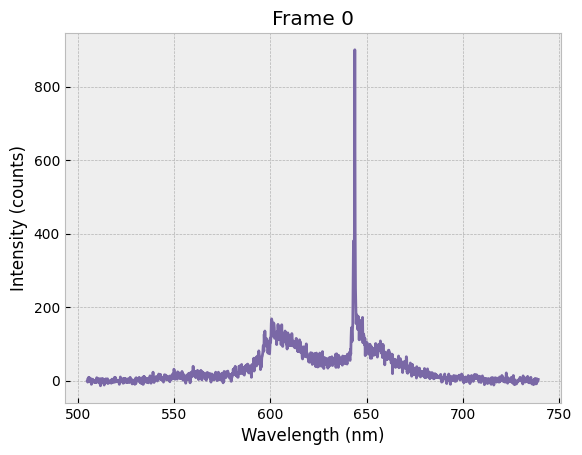

Detecting cosmic ray frames...
Only one frame detected — skipping cosmic ray detection.
Removing cosmic rays from 0 frames: []
Running simple bad frame detection...
Only one frame detected — skipping bad frame detection.
Removing 0 frames: []
Averaging and normalising frames into a single spectrum...
Successfully averaged and normalised frames.


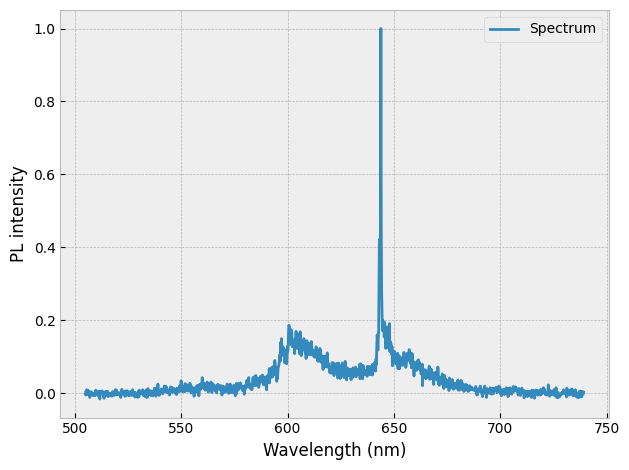

Estimated ZPL: 643.864539228727


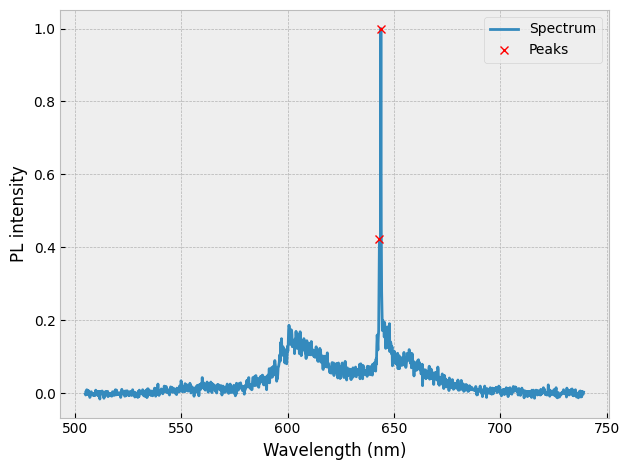

[{'location': np.float64(643.1649321979535), 'intensity': np.float64(0.42219601795999817), 'fwhm': np.float64(0.17490239673065844), 'prominence': np.float64(0.12889473445507732)}, {'location': np.float64(643.864539228727), 'intensity': np.float64(1.0), 'fwhm': np.float64(0.1749013735201288), 'prominence': np.float64(0.8855957186266951)}]
Found ZPL-like peaks at: [643.1649322  643.86453923]
Performing multi-ZPL correction...
Correction complete.


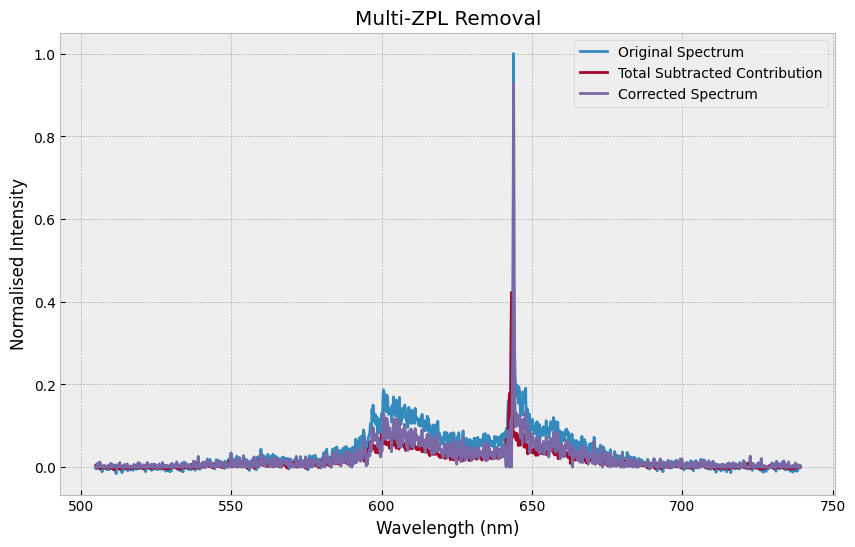

Saved: C:\Users\ech77\OneDrive - University of Cambridge\Data Jan 2026\Large PL study, 0T\2026 January 23 10_51_27 Sample7_capped_500uW_grating150_exposure20_emitter 1_cleaned.npz
Saved: C:\Users\ech77\OneDrive - University of Cambridge\Data Jan 2026\Large PL study, 0T\2026 January 23 10_51_27 Sample7_capped_500uW_grating150_exposure20_emitter 1_cleaned.png
Updated: C:\Users\ech77\OneDrive - University of Cambridge\Data Jan 2026\Large PL study, 0T\ZPL_wavelengths.csv

Saved results for file: 2026 January 23 10_51_27 Sample7_capped_500uW_grating150_exposure20_emitter 1.spe

Processing: 2026 January 23 10_52_33 Sample7_capped_500uW_grating150_exposure20_emitter 2.spe
Performing background subtraction...
Successfully subtracted background.


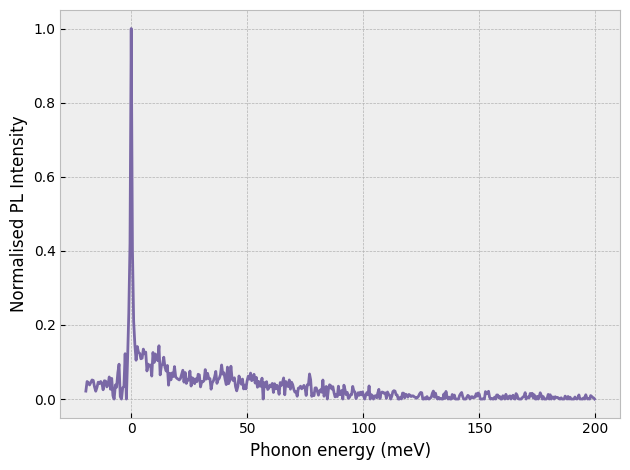

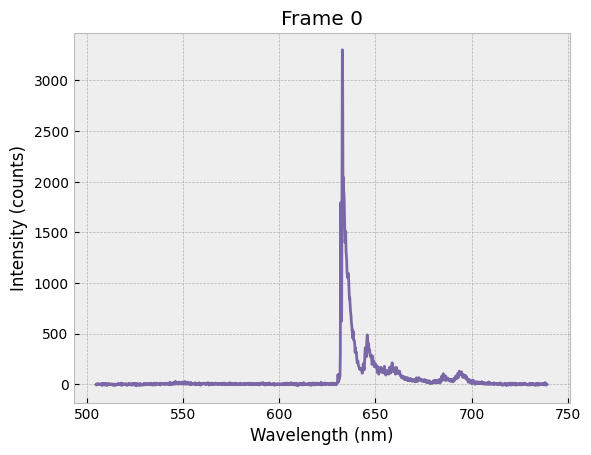

Detecting cosmic ray frames...
Only one frame detected — skipping cosmic ray detection.
Removing cosmic rays from 0 frames: []
Running simple bad frame detection...
Only one frame detected — skipping bad frame detection.
Removing 0 frames: []
Averaging and normalising frames into a single spectrum...
Successfully averaged and normalised frames.


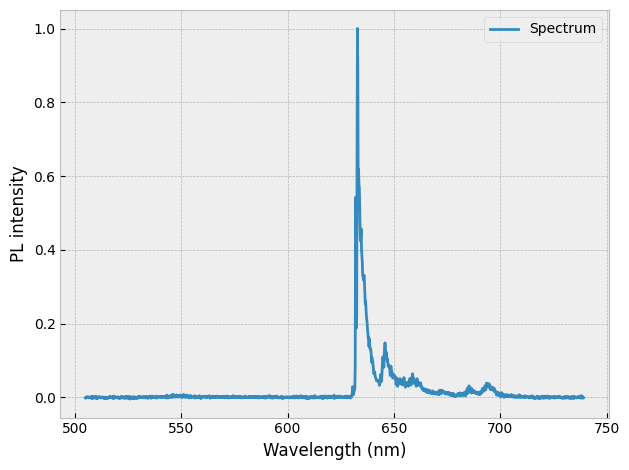

Estimated ZPL: 632.8452669245966


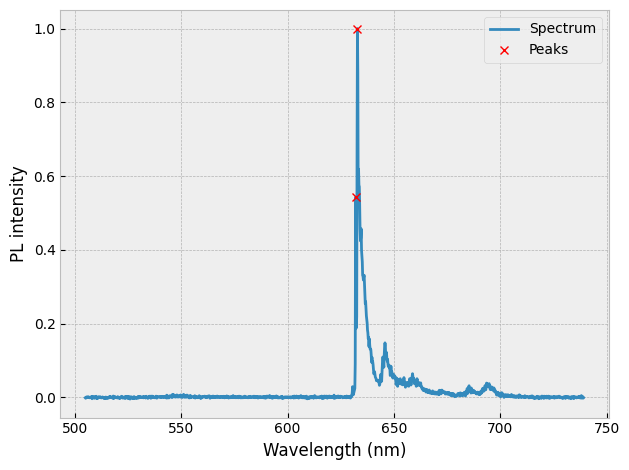

[{'location': np.float64(631.9706806447375), 'intensity': np.float64(0.5426872608827329), 'fwhm': np.float64(0.3498356710039161), 'prominence': np.float64(0.35464451490484755)}, {'location': np.float64(632.8452669245966), 'intensity': np.float64(1.0), 'fwhm': np.float64(1.3993296550924015), 'prominence': np.float64(0.8246772110041843)}]
Found ZPL-like peaks at: [631.97068064 632.84526692]
Performing multi-ZPL correction...
Correction complete.


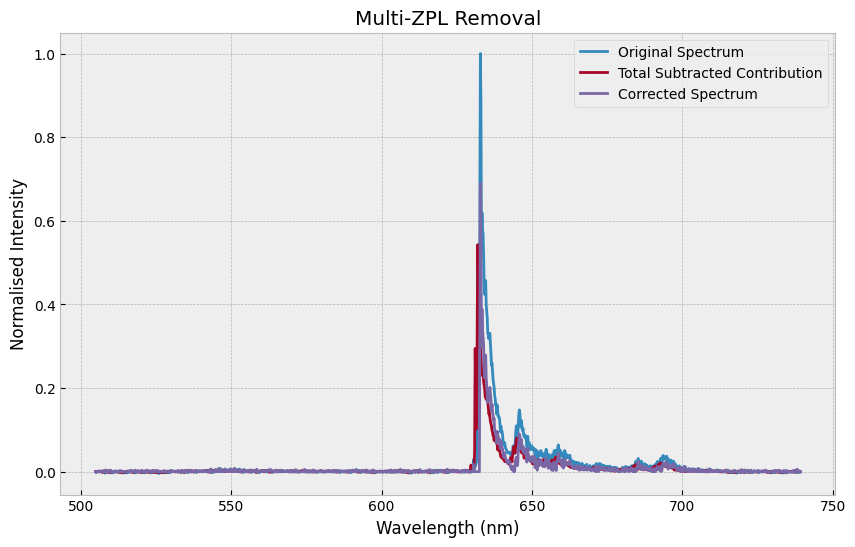

Saved: C:\Users\ech77\OneDrive - University of Cambridge\Data Jan 2026\Large PL study, 0T\2026 January 23 10_52_33 Sample7_capped_500uW_grating150_exposure20_emitter 2_cleaned.npz
Saved: C:\Users\ech77\OneDrive - University of Cambridge\Data Jan 2026\Large PL study, 0T\2026 January 23 10_52_33 Sample7_capped_500uW_grating150_exposure20_emitter 2_cleaned.png
Updated: C:\Users\ech77\OneDrive - University of Cambridge\Data Jan 2026\Large PL study, 0T\ZPL_wavelengths.csv

Saved results for file: 2026 January 23 10_52_33 Sample7_capped_500uW_grating150_exposure20_emitter 2.spe

Processing: 2026 January 23 10_54_31 Sample7_capped_500uW_grating150_exposure20_emitter 3.spe
Performing background subtraction...
Successfully subtracted background.


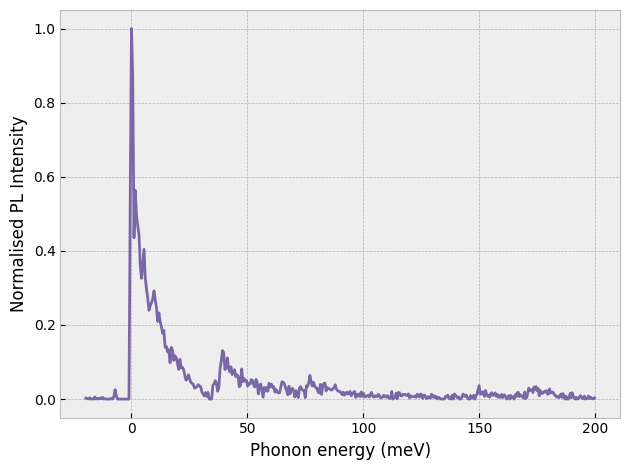

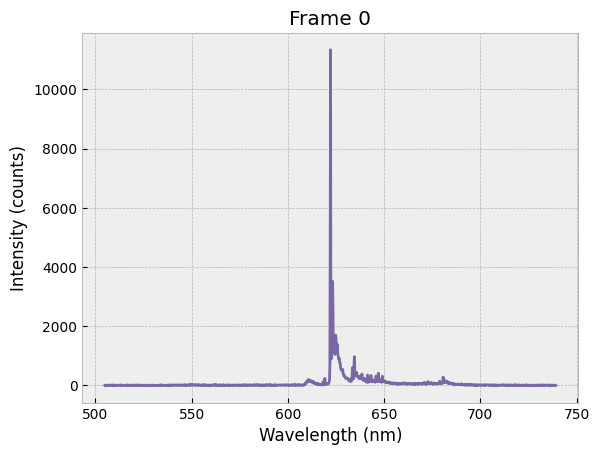

Detecting cosmic ray frames...
Only one frame detected — skipping cosmic ray detection.
Removing cosmic rays from 0 frames: []
Running simple bad frame detection...
Only one frame detected — skipping bad frame detection.
Removing 0 frames: []
Averaging and normalising frames into a single spectrum...
Successfully averaged and normalised frames.


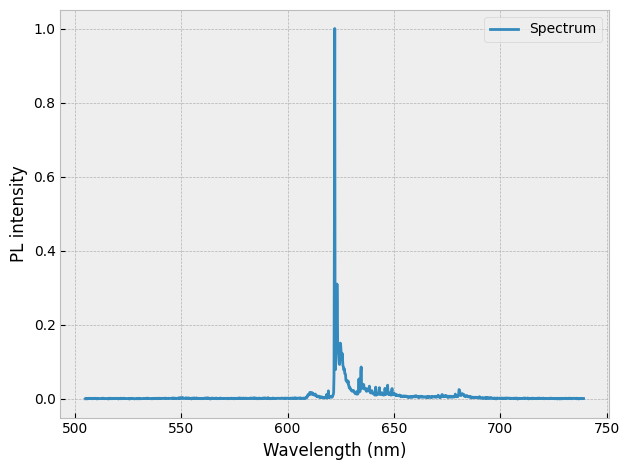

Estimated ZPL: 622.1749302999019


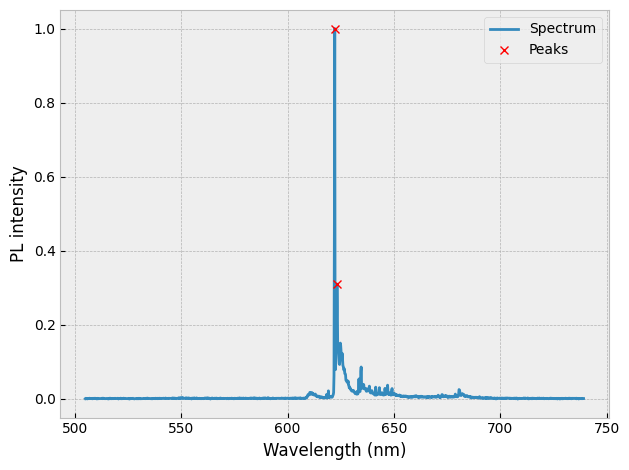

[{'location': np.float64(622.1749302999019), 'intensity': np.float64(1.0), 'fwhm': np.float64(0.17493029990191644), 'prominence': np.float64(0.9330092056111763)}, {'location': np.float64(623.2245076721188), 'intensity': np.float64(0.30945680416303795), 'fwhm': np.float64(0.5247870989633157), 'prominence': np.float64(0.23135665805365024)}]
Found ZPL-like peaks at: [622.1749303  623.22450767]
Performing multi-ZPL correction...
Correction complete.


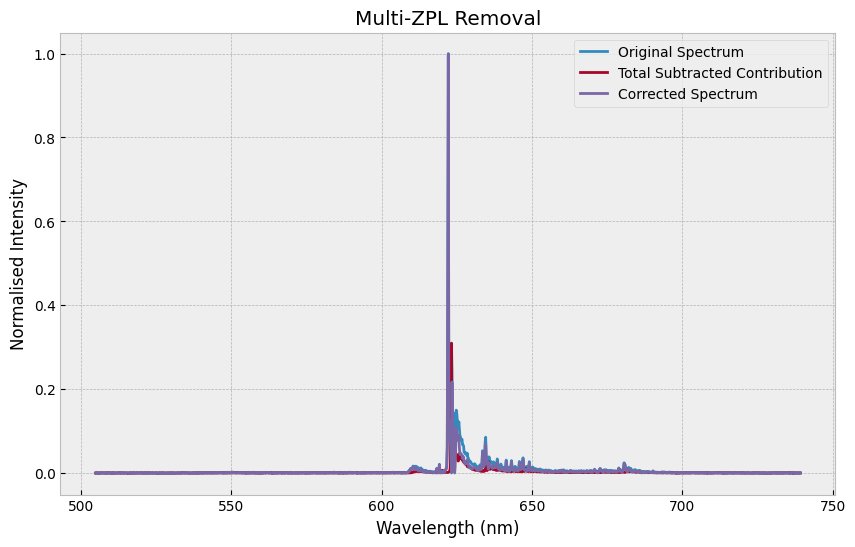

SystemExit: User aborted batch processing.

c:\Users\ech77\AppData\Local\miniconda3\envs\tara_env\Lib\site-packages\IPython\core\interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


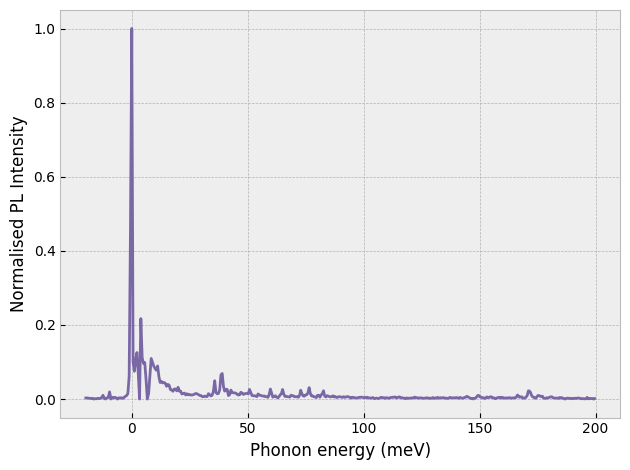

In [2]:
DATA_DIR = Path("C://Users/ech77/OneDrive - University of Cambridge/Data Jan 2026/Large PL study, 0T")

WAIT_FOR_CONFIRM = True   # pause between files so user can inspect plots

batch_process(DATA_DIR, WAIT_FOR_CONFIRM)